<h2><font color="#004D7F" size=6>Módulo 3. Machine Learning</font></h2>



<h1><font color="#004D7F" size=5> Arboles de Decisión</font></h1>

<br><br>
<div style="text-align: right">
<font color="#004D7F" size=3>Seminario en Ciencia de Datos</font><br>


### Introducción

En este módulo, aprenderemos sobre los árboles de decisión, una de las técnicas más interpretables en Machine Learning. Veremos cómo aplicarlos a un conjunto de datos médicos para identificar patrones y predecir problemas cardíacos.

**Objetivos**:
- Comprender la estructura y funcionamiento de un árbol de decisión.
- Entrenar y evaluar un modelo de árbol de decisión.
- Visualizar y analizar la estructura del árbol generado.

Análisis Exploratorio de Datos
Primero, exploraremos el conjunto de datos para comprender su estructura y características.

# Gráfica dispersión: Edad y Colesterol

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Resumen del dataset
pacientes = pd.read_csv("pacientes.csv")


### Relación entre Edad, Colesterol y Problemas Cardíacos

A continuación, visualizamos la relación entre edad, colesterol y la presencia de problemas cardíacos.

In [8]:
# Scatterplot para visualizar relaciones
print("Resumen de datos:")
pacientes.info()
print("Mostrar las primeras filas:")
pacientes.head()

Resumen de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   edad               300 non-null    int64
 1   colesterol         300 non-null    int64
 2   problema_cardiaco  300 non-null    int64
dtypes: int64(3)
memory usage: 7.2 KB
Mostrar las primeras filas:


,edad,colesterol,problema_cardiaco
0,63,233,1
1,37,250,1
2,41,204,1
3,56,236,1
4,57,354,1


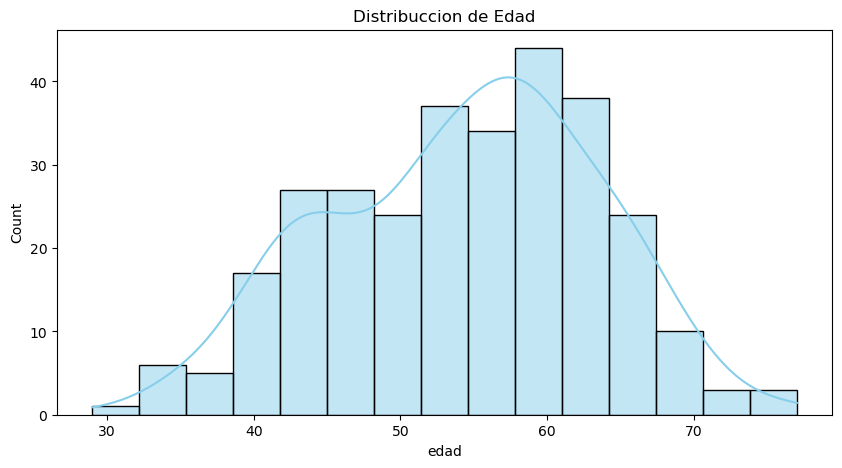

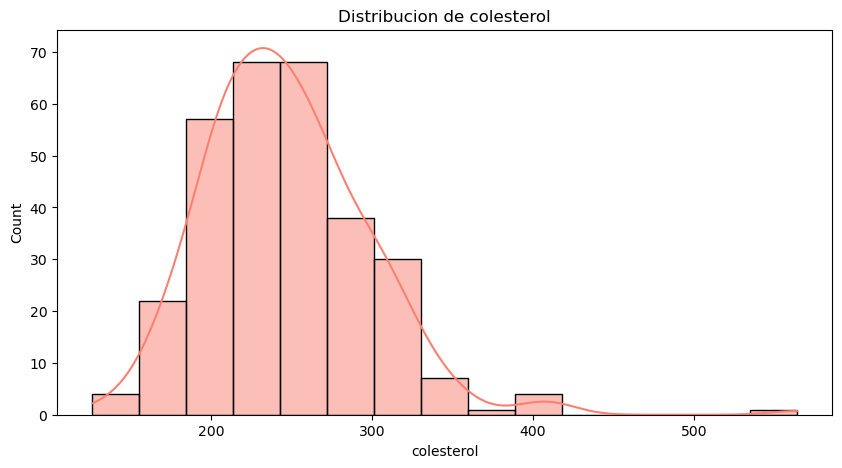

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(pacientes['edad'], kde=True, bins=15, color='skyblue')
plt.title("Distribuccion de Edad")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(pacientes['colesterol'], kde=True, bins=15, color='salmon')
plt.title("Distribucion de colesterol")
plt.show()

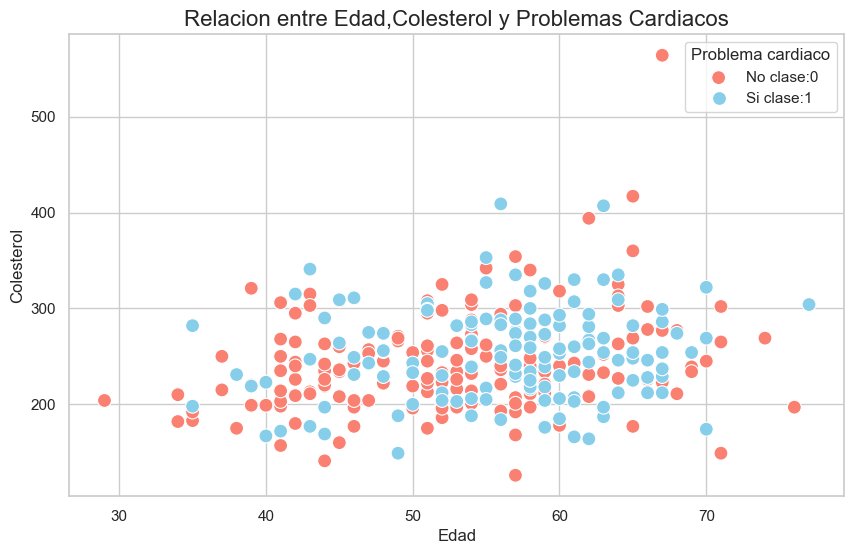

In [29]:
# Grafico de dispersion
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='edad',
    y='colesterol',
    hue='problema_cardiaco',
    data=pacientes,
    palette=["skyblue","salmon"],
    s=100
)
plt.title("Relacion entre Edad,Colesterol y Problemas Cardiacos", fontsize=16)
plt.xlabel("Edad")
plt.ylabel("Colesterol")
plt.legend(title="Problema cardiaco", labels=["No clase:0","Si clase:1"])
plt.show()

# Datos de Entrenamiento y Prueba

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

x = pacientes[['edad','colesterol']]
y = pacientes['problema_cardiaco']


X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)


# Creación del Árbol de Decisión

Usaremos el algoritmo de árboles de decisión para predecir si un paciente tiene problemas cardíacos en función de su edad y nivel de colesterol.

In [40]:
from sklearn import tree

#Crear y entrenar el modelo
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [50]:
# Evaluar el modelo
y_pred = tree.predict(X_test)
print("Reporte de Clasificacion", classification_report(y_test,y_pred))
print("Matriz de Confucion", confusion_matrix(y_test,y_pred))

Reporte de Clasificacion               precision    recall  f1-score   support

           0       0.49      0.59      0.54        37
           1       0.67      0.57      0.61        53

    accuracy                           0.58        90
   macro avg       0.58      0.58      0.57        90
weighted avg       0.59      0.58      0.58        90

Matriz de Confucion [[22 15]
 [23 30]]


[Text(0.5, 0.875, 'Edad <= 55.5\ngini = 0.498\nsamples = 210\nvalue = [98, 112]\nclass = Si'),
 Text(0.25, 0.625, 'Edad <= 45.5\ngini = 0.455\nsamples = 100\nvalue = [35, 65]\nclass = Si'),
 Text(0.125, 0.375, 'Colesterol <= 201.0\ngini = 0.402\nsamples = 43\nvalue = [12.0, 31.0]\nclass = Si'),
 Text(0.0625, 0.125, 'gini = 0.496\nsamples = 11\nvalue = [5, 6]\nclass = Si'),
 Text(0.1875, 0.125, 'gini = 0.342\nsamples = 32\nvalue = [7, 25]\nclass = Si'),
 Text(0.375, 0.375, 'Edad <= 50.5\ngini = 0.481\nsamples = 57\nvalue = [23, 34]\nclass = Si'),
 Text(0.3125, 0.125, 'gini = 0.495\nsamples = 20\nvalue = [11, 9]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.438\nsamples = 37\nvalue = [12, 25]\nclass = Si'),
 Text(0.75, 0.625, 'Edad <= 63.5\ngini = 0.489\nsamples = 110\nvalue = [63, 47]\nclass = No'),
 Text(0.625, 0.375, 'Colesterol <= 248.5\ngini = 0.461\nsamples = 75\nvalue = [48, 27]\nclass = No'),
 Text(0.5625, 0.125, 'gini = 0.5\nsamples = 41\nvalue = [21, 20]\nclass = No'),
 Text(0.

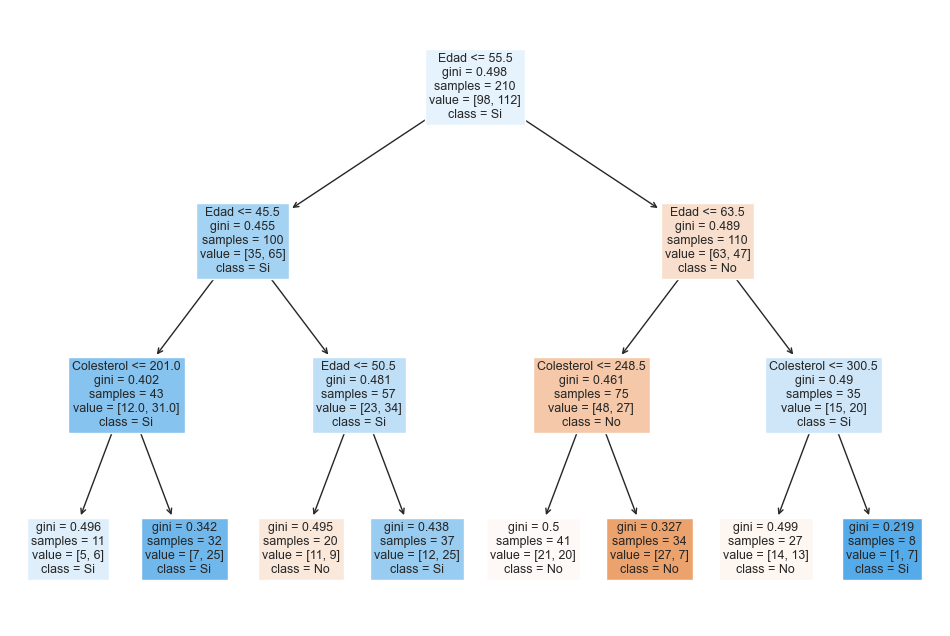

In [52]:
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=['Edad','Colesterol'], class_names=['No','Si'], filled=True)

<BR><BR>

# Clasifica a nuevos pacientes

In [54]:
# Predicción para un nuevo paciente
nueva_prediccion= tree.predict([[70,320]])
print("Prediccion", "Problema Cardiaco" if  nueva_prediccion[0]==1 else "No presenta problema")

Prediccion Problema Cardiaco


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



### Evaluación del Modelo

Finalmente, evaluaremos el desempeño del modelo utilizando métricas como precisión, sensibilidad y la matriz de confusión.


In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

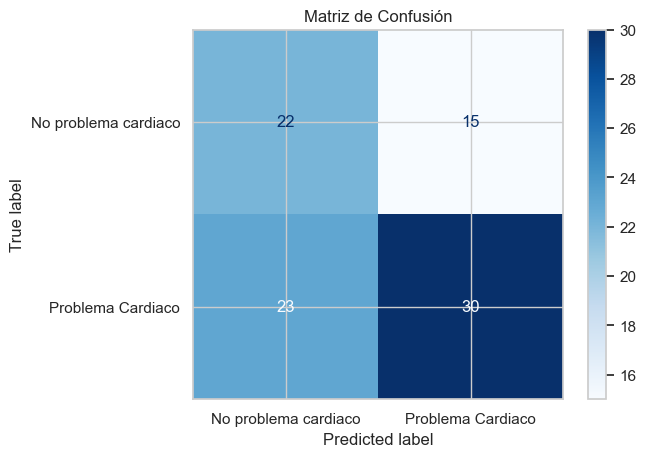

In [58]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No problema cardiaco","Problema Cardiaco"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.show()